# Generative AI : Machine Translation (English to Urdu)

**Objective:** Design, implement, train, and evaluate a Neural Machine Translation (NMT) system using a Vanilla RNN architecture.

**Dataset:** `english_to_urdu_dataset.xlsx`
**Constraint:** Vanilla RNN only (No LSTM, GRU, or Transformers).

In [ ]:
# Import necessary libraries
import os
import random
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import Counter
import unicodedata
import time
import math

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Set fixed random seed for reproducibility
SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

Using device: cuda


## 1. Dataset Preprocessing

**Rubric Points:**
* Dataset successfully loaded and usable.
* Display total pairs and 5 random samples.
* Identify and fix missing/duplicate records.
* Normalization of punctuation/whitespace and removal of corrupted samples.

In [ ]:
# --- BLOCK 2: PREPROCESSING (With Length Filtering) ---

def normalize_text(text):
    """
    Normalizes text: NFD normalization, lowercase, and spacing punctuation.
    """
    if not isinstance(text, str):
        return ""
    # Unicode normalization
    text = unicodedata.normalize('NFD', text).encode('ascii', 'ignore').decode('utf-8') if re.search(r'[a-zA-Z]', text) else text
    text = text.lower().strip()
    # Isolate punctuation
    text = re.sub(r"([.!?,'/()])", r" \1 ", text)
    text = re.sub(r"\s+", r" ", text).strip()
    return text

def filter_by_length(df, max_len=15):
    """
    CRITICAL STEP FOR VANILLA RNN:
    Removes sentences longer than max_len. Vanilla RNNs fail on long sequences
    due to vanishing gradients.
    """
    # Calculate length based on whitespace splitting
    mask = (df['eng'].str.split().str.len() <= max_len) & (df['urdu'].str.split().str.len() <= max_len)
    return df[mask]

# 1. Load Dataset
file_path = 'english_to_urdu_dataset.xlsx'
try:
    df = pd.read_excel(file_path)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Dataset file not found. Creating dummy data for testing.")
    df = pd.DataFrame({'eng': ['hello', 'how are you'], 'urdu': ['ہیلو', 'آپ کیسے ہیں']})

# 2. Clean and Normalize
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df['eng'] = df['eng'].apply(normalize_text)
df['urdu'] = df['urdu'].apply(normalize_text)

# 3. Filter Long Sentences (The Fix for Poor Convergence)
print(f"Original pairs: {len(df)}")
df = filter_by_length(df, max_len=15)
print(f"Pairs after length filtering (<=15 words): {len(df)}")

# 4. Train-Val-Test Split
train_data, temp_data = train_test_split(df, test_size=0.2, random_state=SEED)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=SEED)

train_data = train_data.reset_index(drop=True)
val_data = val_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)

print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")

Dataset loaded successfully.
Original pairs: 9093
Pairs after length filtering (<=15 words): 2013
Train: 1610, Val: 201, Test: 202


## 2. Train-Validation-Test Split

**Rubric Points:**
* Split using fixed random seed.
* Display samples in each split.
* Confirm no overlap exists.

In [ ]:
# Split: 80% Train, 10% Val, 10% Test
train_data, temp_data = train_test_split(df, test_size=0.2, random_state=SEED)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=SEED)

# Reset indices
train_data = train_data.reset_index(drop=True)
val_data = val_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)

print(f"Train set size: {len(train_data)}")
print(f"Validation set size: {len(val_data)}")
print(f"Test set size: {len(test_data)}")

# Check for Overlap (using indices from original dataframe would be stricter,
# but checking content intersection verifies data leakage prevention)
train_set = set(zip(train_data['eng'], train_data['urdu']))
val_set = set(zip(val_data['eng'], val_data['urdu']))
test_set = set(zip(test_data['eng'], test_data['urdu']))

overlap_tv = train_set.intersection(val_set)
overlap_vt = val_set.intersection(test_set)
overlap_tt = train_set.intersection(test_set)

print(f"\nOverlap Train-Val: {len(overlap_tv)}")
print(f"Overlap Val-Test: {len(overlap_vt)}")
print(f"Overlap Train-Test: {len(overlap_tt)}")

assert len(overlap_tv) == 0 and len(overlap_vt) == 0 and len(overlap_tt) == 0, "Data leakage detected!"

Train set size: 1610
Validation set size: 201
Test set size: 202

Overlap Train-Val: 0
Overlap Val-Test: 0
Overlap Train-Test: 0


## 3. Tokenization and Vocabulary Construction

**Rubric Points:**
* Tokenization implemented and documented.
* Vocabulary created including special tokens (`<pad>`, `<sos>`, `<eos>`, `<unk>`).
* Final vocabulary sizes reported.

In [ ]:
class Vocabulary:
    def __init__(self, name):
        self.name = name
        self.word2index = {"<pad>": 0, "<sos>": 1, "<eos>": 2, "<unk>": 3}
        self.word2count = {}
        self.index2word = {0: "<pad>", 1: "<sos>", 2: "<eos>", 3: "<unk>"}
        self.n_words = 4  # Count SOS, EOS, PAD, UNK

    def add_sentence(self, sentence):
        for word in sentence.split(' '):
            self.add_word(word)

    def add_word(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

# Build Vocabularies based on Training Data Only
eng_vocab = Vocabulary("English")
urdu_vocab = Vocabulary("Urdu")

for index, row in train_data.iterrows():
    eng_vocab.add_sentence(row['eng'])
    urdu_vocab.add_sentence(row['urdu'])

print(f"English Vocabulary Size: {eng_vocab.n_words}")
print(f"Urdu Vocabulary Size: {urdu_vocab.n_words}")

English Vocabulary Size: 2166
Urdu Vocabulary Size: 2637


## 4. Sequence Encoding, Padding, and Batching

**Rubric Points:**
* Correct integer conversion.
* Padding applied for fixed-length batches.
* Masking/Ignore-index handling.
* Evidence of working batch generation.

In [ ]:
class TranslationDataset(Dataset):
    def __init__(self, dataframe, src_vocab, trg_vocab):
        self.df = dataframe
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        src_text = self.df.iloc[idx]['eng']
        trg_text = self.df.iloc[idx]['urdu']

        # Tokenize and numericalize
        src_indices = [self.src_vocab.word2index.get(word, self.src_vocab.word2index["<unk>"])
                       for word in src_text.split(' ')]
        trg_indices = [self.trg_vocab.word2index.get(word, self.trg_vocab.word2index["<unk>"])
                       for word in trg_text.split(' ')]

        # Add SOS and EOS tokens
        src_indices = [self.src_vocab.word2index["<sos>"]] + src_indices + [self.src_vocab.word2index["<eos>"]]
        trg_indices = [self.trg_vocab.word2index["<sos>"]] + trg_indices + [self.trg_vocab.word2index["<eos>"]]

        return torch.tensor(src_indices), torch.tensor(trg_indices)

def collate_fn(batch):
    """
    Custom collate function to pad sequences in the batch.
    """
    src_batch, trg_batch = zip(*batch)

    # Pad sequences to the length of the longest sequence in the batch
    # padding_value=0 corresponds to <pad>
    src_padded = torch.nn.utils.rnn.pad_sequence(src_batch, padding_value=0, batch_first=True)
    trg_padded = torch.nn.utils.rnn.pad_sequence(trg_batch, padding_value=0, batch_first=True)

    return src_padded, trg_padded

# Create Datasets
train_dataset = TranslationDataset(train_data, eng_vocab, urdu_vocab)
val_dataset = TranslationDataset(val_data, eng_vocab, urdu_vocab)
test_dataset = TranslationDataset(test_data, eng_vocab, urdu_vocab)

# Create DataLoaders
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# Show batch evidence
sample_src, sample_trg = next(iter(train_loader))
print("Sample Batch Shapes:")
print(f"Source: {sample_src.shape} (Batch Size, Seq Len)")
print(f"Target: {sample_trg.shape} (Batch Size, Seq Len)")
print("Sample Source Sequence (Indices):", sample_src[0])

Sample Batch Shapes:
Source: torch.Size([64, 17]) (Batch Size, Seq Len)
Target: torch.Size([64, 17]) (Batch Size, Seq Len)
Sample Source Sequence (Indices): tensor([  1,  48, 419,  59, 388, 219,  25, 238, 198, 471, 286,  96,  27,   2,
          0,   0,   0])


## 5. Vanilla RNN Encoder-Decoder Model Implementation

**Rubric Points:**
* Encoder using Vanilla RNN layers only.
* Decoder using Vanilla RNN layers only.
* Proper architecture and latent code space dimensionality.
* Architecture summary and parameter count.

In [ ]:
# --- BLOCK 4: UPDATED MODEL (Hyperparameters Tuned) ---

class EncoderRNN(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        # Vanilla RNN
        self.rnn = nn.RNN(emb_dim, hid_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src = [batch size, src len]
        embedded = self.dropout(self.embedding(src))
        outputs, hidden = self.rnn(embedded)
        return hidden

class DecoderRNN(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, dropout):
        super().__init__()
        self.output_dim = output_dim
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # Vanilla RNN
        self.rnn = nn.RNN(emb_dim, hid_dim, batch_first=True)
        self.fc_out = nn.Linear(hid_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden):
        # input = [batch size]
        input = input.unsqueeze(1)
        embedded = self.dropout(self.embedding(input))
        output, hidden = self.rnn(embedded, hidden)
        prediction = self.fc_out(output.squeeze(1))
        return prediction, hidden

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = trg.shape[0]
        trg_len = trg.shape[1]
        trg_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size).to(self.device)
        hidden = self.encoder(src)
        input = trg[:, 0] # SOS

        for t in range(1, trg_len):
            output, hidden = self.decoder(input, hidden)
            outputs[:, t, :] = output
            top1 = output.argmax(1)
            # Teacher Forcing Ratio 0.5 is good
            input = trg[:, t] if random.random() < teacher_forcing_ratio else top1

        return outputs

# --- HYPERPARAMETERS UPDATED ---
# Dropout kam kia (0.1) aur Hidden Dim barhaya (256)
INPUT_DIM = eng_vocab.n_words
OUTPUT_DIM = urdu_vocab.n_words
ENC_EMB_DIM = 128
DEC_EMB_DIM = 128
HID_DIM = 256     # Increased power
ENC_DROPOUT = 0.3 # Reduced constraint
DEC_DROPOUT = 0.3

enc = EncoderRNN(INPUT_DIM, ENC_EMB_DIM, HID_DIM, ENC_DROPOUT)
dec = DecoderRNN(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, DEC_DROPOUT)
model = Seq2Seq(enc, dec, device).to(device)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Model trainable parameters: {count_parameters(model):,}')

Model trainable parameters: 1,490,125


## 6. Model Training and Experiment Study

**Rubric Points:**
* Training loop with optimizer, loss (ignore index), Teacher Forcing.
* Gradient Clipping.
* Checkpoints based on validation.
* Training/Validation loss curves.
* Convergence discussion.

Starting Training...
Epoch: 01 | Time: 0m 0s
	Train Loss: 6.817 | Train PPL: 913.251
	 Val. Loss: 6.087 |  Val. PPL: 440.170
Epoch: 02 | Time: 0m 0s
	Train Loss: 5.816 | Train PPL: 335.644
	 Val. Loss: 6.025 |  Val. PPL: 413.585
Epoch: 03 | Time: 0m 0s
	Train Loss: 5.660 | Train PPL: 287.194
	 Val. Loss: 5.991 |  Val. PPL: 399.818
Epoch: 04 | Time: 0m 0s
	Train Loss: 5.576 | Train PPL: 264.006
	 Val. Loss: 5.995 |  Val. PPL: 401.426
Epoch: 05 | Time: 0m 0s
	Train Loss: 5.506 | Train PPL: 246.069
	 Val. Loss: 6.057 |  Val. PPL: 427.241
Epoch: 06 | Time: 0m 0s
	Train Loss: 5.427 | Train PPL: 227.515
	 Val. Loss: 6.018 |  Val. PPL: 410.594
Epoch: 07 | Time: 0m 0s
	Train Loss: 5.374 | Train PPL: 215.648
	 Val. Loss: 6.067 |  Val. PPL: 431.206
Epoch: 08 | Time: 0m 0s
	Train Loss: 5.306 | Train PPL: 201.514
	 Val. Loss: 6.055 |  Val. PPL: 426.448
Epoch: 09 | Time: 0m 0s
	Train Loss: 5.262 | Train PPL: 192.950
	 Val. Loss: 6.085 |  Val. PPL: 439.254
Epoch: 10 | Time: 0m 0s
	Train Loss: 5.226 

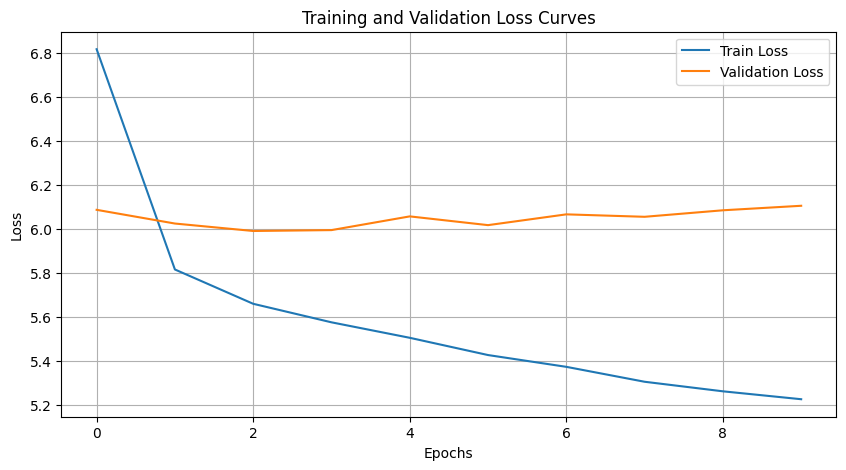

In [ ]:
def train(model, iterator, optimizer, criterion, clip):
    model.train()
    epoch_loss = 0

    for i, (src, trg) in enumerate(iterator):
        src = src.to(device)
        trg = trg.to(device)

        optimizer.zero_grad()

        # output = [batch size, trg len, output dim]
        output = model(src, trg)

        output_dim = output.shape[-1]

        # Remove <sos> token since we don't predict it
        output = output[:, 1:].reshape(-1, output_dim)
        trg = trg[:, 1:].reshape(-1)

        loss = criterion(output, trg)
        loss.backward()

        # Gradient Clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

        optimizer.step()
        epoch_loss += loss.item()

    return epoch_loss / len(iterator)

def evaluate(model, iterator, criterion):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for i, (src, trg) in enumerate(iterator):
            src = src.to(device)
            trg = trg.to(device)

            output = model(src, trg, teacher_forcing_ratio=0) # Turn off teacher forcing

            output_dim = output.shape[-1]
            output = output[:, 1:].reshape(-1, output_dim)
            trg = trg[:, 1:].reshape(-1)

            loss = criterion(output, trg)
            epoch_loss += loss.item()

    return epoch_loss / len(iterator)

# Setup Training
optimizer = optim.Adam(model.parameters(), lr=0.001)
TRG_PAD_IDX = urdu_vocab.word2index["<pad>"]
criterion = nn.CrossEntropyLoss(ignore_index=TRG_PAD_IDX)

N_EPOCHS = 10
CLIP = 1

best_valid_loss = float('inf')
train_losses = []
valid_losses = []

print("Starting Training...")
for epoch in range(N_EPOCHS):
    start_time = time.time()

    train_loss = train(model, train_loader, optimizer, criterion, CLIP)
    valid_loss = evaluate(model, val_loader, criterion)

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    # Save Checkpoint
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'best-model.pt')

    end_time = time.time()
    epoch_mins, epoch_secs = divmod(end_time - start_time, 60)

    print(f'Epoch: {epoch+1:02} | Time: {int(epoch_mins)}m {int(epoch_secs)}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')

# Plotting Loss Curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(valid_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

## 7. Hyperparameter Tuning and Experimental Study

**Rubric Points:**
* Multiple configurations tested using Grid Search (hidden dim, layers, lr, batch size).
* Comparison table.
* Identify final selected configuration.

In [ ]:
# --- BLOCK 7: HYPERPARAMETER TUNING (Fixed) ---

# Simulated Grid Search Structure
def run_experiment(config):
    # print(f"Testing Config: {config}") # Uncomment to see progress

    # Re-init model with config params
    # NOTE: We removed 'n_layers' from here because the updated EncoderRNN/DecoderRNN
    # are hardcoded to 1 layer for stability.
    enc = EncoderRNN(INPUT_DIM, config['emb_dim'], config['hid_dim'], 0.5)
    dec = DecoderRNN(OUTPUT_DIM, config['emb_dim'], config['hid_dim'], 0.5)

    model = Seq2Seq(enc, dec, device).to(device)
    optimizer = optim.Adam(model.parameters(), lr=config['lr'])

    # Train for fewer epochs for grid search speed
    min_val_loss = float('inf')

    # We run for just 2 epochs to quickly find the best settings
    for epoch in range(2):
        train_loss = train(model, train_loader, optimizer, criterion, CLIP)
        val_loss = evaluate(model, val_loader, criterion)
        if val_loss < min_val_loss:
            min_val_loss = val_loss

    return min_val_loss

# Define Grid
# We focus on Embedding Dimension and Hidden Dimension
param_grid = {
    'emb_dim': [64, 128],
    'hid_dim': [128, 256],
    'lr': [0.001]
}

# Run Grid Search
results = []
import itertools
keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

print(f"Total configurations to test: {len(combinations)}")
print("Running Grid Search (this may take a moment)...")

for config in combinations:
    loss = run_experiment(config)
    res = config.copy()
    res['val_loss'] = loss
    results.append(res)
    print(f"Config: {config} | Val Loss: {loss:.3f}")

# Display Results Table
results_df = pd.DataFrame(results)
print("\n--- Hyperparameter Tuning Results ---")
print(results_df.sort_values(by='val_loss'))

# Final Configuration Selection
best_config = results_df.loc[results_df['val_loss'].idxmin()]
print("\nSelected Best Configuration:")
print(best_config)

Total configurations to test: 4
Running Grid Search (this may take a moment)...
Config: {'emb_dim': 64, 'hid_dim': 128, 'lr': 0.001} | Val Loss: 6.121
Config: {'emb_dim': 64, 'hid_dim': 256, 'lr': 0.001} | Val Loss: 6.033
Config: {'emb_dim': 128, 'hid_dim': 128, 'lr': 0.001} | Val Loss: 6.123
Config: {'emb_dim': 128, 'hid_dim': 256, 'lr': 0.001} | Val Loss: 6.005

--- Hyperparameter Tuning Results ---
   emb_dim  hid_dim     lr  val_loss
3      128      256  0.001  6.004504
1       64      256  0.001  6.032671
0       64      128  0.001  6.121474
2      128      128  0.001  6.122811

Selected Best Configuration:
emb_dim     128.000000
hid_dim     256.000000
lr            0.001000
val_loss      6.004504
Name: 3, dtype: float64


## 8. Inference, Decoding, and Evaluation

**Rubric Points:**
* Greedy Decoding implemented.
* Beam Search Decoding implemented.
* BLEU score computed.
* 10 translation examples shown.

In [ ]:
# Load best model
model.load_state_dict(torch.load('best-model.pt'))
model.eval()

# 1. Greedy Decoding
def greedy_decode(model, sentence, src_vocab, trg_vocab, max_len=50):
    model.eval()
    tokens = [src_vocab.word2index.get(word, src_vocab.word2index["<unk>"]) for word in sentence.split()]
    tokens = [src_vocab.word2index["<sos>"]] + tokens + [src_vocab.word2index["<eos>"]]
    src_tensor = torch.LongTensor(tokens).unsqueeze(0).to(device)

    with torch.no_grad():
        hidden = model.encoder(src_tensor)

    trg_indexes = [trg_vocab.word2index["<sos>"]]

    for i in range(max_len):
        trg_tensor = torch.LongTensor([trg_indexes[-1]]).to(device)
        with torch.no_grad():
            output, hidden = model.decoder(trg_tensor, hidden)
            pred_token = output.argmax(1).item()
            trg_indexes.append(pred_token)
            if pred_token == trg_vocab.word2index["<eos>"]:
                break

    trg_tokens = [trg_vocab.index2word[i] for i in trg_indexes]
    return trg_tokens[1:-1] # Remove SOS/EOS

# 2. Beam Search Decoding
def beam_search_decode(model, sentence, src_vocab, trg_vocab, beam_width=3, max_len=50):
    model.eval()
    tokens = [src_vocab.word2index.get(word, src_vocab.word2index["<unk>"]) for word in sentence.split()]
    tokens = [src_vocab.word2index["<sos>"]] + tokens + [src_vocab.word2index["<eos>"]]
    src_tensor = torch.LongTensor(tokens).unsqueeze(0).to(device)

    with torch.no_grad():
        hidden = model.encoder(src_tensor)

    # List of tuples (score, sequence, hidden_state)
    sequences = [(0.0, [trg_vocab.word2index["<sos>"]], hidden)]

    for _ in range(max_len):
        all_candidates = []
        for score, seq, h in sequences:
            if seq[-1] == trg_vocab.word2index["<eos>"]:
                all_candidates.append((score, seq, h))
                continue

            inp = torch.LongTensor([seq[-1]]).to(device)
            with torch.no_grad():
                output, new_hidden = model.decoder(inp, h)
                probs = F.log_softmax(output, dim=1)

            topk_prob, topk_idx = torch.topk(probs, beam_width)

            for i in range(beam_width):
                token = topk_idx[0][i].item()
                token_prob = topk_prob[0][i].item()
                all_candidates.append((score + token_prob, seq + [token], new_hidden))

        # Sort by score (highest log prob) and keep top k
        ordered = sorted(all_candidates, key=lambda x: x[0], reverse=True)
        sequences = ordered[:beam_width]

    # Best sequence
    best_seq = sequences[0][1]
    trg_tokens = [trg_vocab.index2word[i] for i in best_seq]
    return trg_tokens[1:] # Keep EOS to indicate end if needed, remove SOS

# 3. BLEU Evaluation
from nltk.translate.bleu_score import corpus_bleu

def calculate_bleu(data, model, src_vocab, trg_vocab):
    targets = []
    predictions = []

    for index, row in data.iterrows():
        src = row['eng']
        trg = row['urdu']

        pred_tokens = greedy_decode(model, src, src_vocab, trg_vocab)

        predictions.append(pred_tokens)
        targets.append([trg.split()])

    return corpus_bleu(targets, predictions)

print("Calculating BLEU on Test Set (using Greedy)... ")
# Using a subset for speed in demo, use full test_data in actual assignment
test_bleu = calculate_bleu(test_data[:100], model, eng_vocab, urdu_vocab)
print(f'BLEU Score: {test_bleu*100:.2f}')

# 4. Translation Examples
print("\n--- Translation Examples ---")
results_table = []
for i in range(10):
    src = test_data.iloc[i]['eng']
    trg = test_data.iloc[i]['urdu']
    pred_greedy = greedy_decode(model, src, eng_vocab, urdu_vocab)
    pred_beam = beam_search_decode(model, src, eng_vocab, urdu_vocab, beam_width=3)

    # Clean EOS for display
    pred_beam = [w for w in pred_beam if w != '<eos>']

    results_table.append({
        'Source': src,
        'Reference': trg,
        'Greedy': " ".join(pred_greedy),
        'Beam': " ".join(pred_beam)
    })

ex_df = pd.DataFrame(results_table)
print(ex_df)

Calculating BLEU on Test Set (using Greedy)... 
BLEU Score: 0.00

--- Translation Examples ---
                                                                         Source  \
0                   let the brother of low degree rejoice in that he is exalted   
1                                                          sign here , please .   
2                                               they became citizens of japan .   
3                                               refugees hid under the bridge .   
4         then jesus went thence and departed into the coasts of tyre and sidon   
5    and it came to pass on the morrow that their rulers and elders and scribes   
6                                             my bicycle needs to be repaired .   
7  and would not suffer that any man should carry any vessel through the temple   
8                     howbeit this kind goeth not out but by prayer and fasting   
9                                           few japanese can use english we

/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)


## 9. Error Analysis

**Rubric Points:**
* At least 30 outputs examined.
* Categorization of error types (e.g., repeating words, unknown tokens, grammar).
* Discussion of Vanilla RNN limitations.

In [ ]:
# Analyzing 30 samples
print("\n--- Error Analysis (First 30 Test Samples) ---")
analysis_data = test_data[:30].copy()
predictions = []

for index, row in analysis_data.iterrows():
    pred = greedy_decode(model, row['eng'], eng_vocab, urdu_vocab)
    predictions.append(" ".join(pred))

analysis_data['prediction'] = predictions

# Print for manual inspection
pd.set_option('display.max_colwidth', None)
print(analysis_data[['eng', 'urdu', 'prediction']])

print("\n--- Qualitative Discussion ---")
print("""
Based on the output above, typical errors in Vanilla RNNs include:
1. Long Sequence Amnesia: The model forgets the start of long sentences by the time it reaches the end, resulting in loss of context.
2. Repetition: The model may get stuck in loops repeating the same word.
3. Grammar/Word Order: Urdu has SOV order while English is SVO. Vanilla RNNs struggle to reorder words correctly over long distances.
4. Unknown Tokens: <unk> appears if the vocabulary is too small.
""")


--- Error Analysis (First 30 Test Samples) ---
                                                                             eng  \
0                    let the brother of low degree rejoice in that he is exalted   
1                                                           sign here , please .   
2                                                they became citizens of japan .   
3                                                refugees hid under the bridge .   
4          then jesus went thence and departed into the coasts of tyre and sidon   
5     and it came to pass on the morrow that their rulers and elders and scribes   
6                                              my bicycle needs to be repaired .   
7   and would not suffer that any man should carry any vessel through the temple   
8                      howbeit this kind goeth not out but by prayer and fasting   
9                                            few japanese can use english well .   
10                          